# ♻️ Waste Classification using Transfer Learning & Fine-Tuning
### VGG16 tabanlı derin öğrenme ile organik ve geri dönüştürülebilir atık sınıflandırması

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/Final_Proj-Classify_Waste_Products_Using_TL_FT.ipynb)

---
**Proje:** IBM / Skills Network — Final Projesi  
**Teknik:** Transfer Learning + Fine-Tuning (VGG16 + ImageNet)  
**Görev:** İkili sınıflandırma — Organik (O) vs Geri Dönüştürülebilir (R)  

---

## 📌 Proje Genel Bakışı

**EcoClean** şirketi atık ayrıştırma sürecini otomatikleştirmek istemektedir.  
Manuel ayrıştırma hem emek yoğun hem de hata prone (geri dönüştürülebilir malzemelerin kirlenmesine yol açıyor).

Bu proje, önceden ImageNet üzerinde eğitilmiş **VGG16** modelini kullanarak **Transfer Learning** ile atık görüntülerini sınıflandırır.

### Öğrenme Hedefleri
- VGG16 ile Transfer Learning uygulamak
- Görüntü verilerini hazırlamak ve ön işleme tabi tutmak (ImageDataGenerator + augmentation)
- Fine-tuning ile model performansını artırmak
- Modeli uygun metriklerle değerlendirmek ve görselleştirmek

## 📋 İçindekiler

1. [Kurulum ve Kütüphaneler](#1-kurulum)
2. [Veri İndirme ve Hazırlama](#2-veri)
3. [ImageDataGenerators](#3-generators)
4. [VGG16 Modeli — Feature Extraction](#4-model)
5. [Modeli Eğitme](#5-egitim)
6. [Fine-Tuning](#6-finetune)
7. [Test ve Değerlendirme](#7-test)

## ⚙️ 1. Kurulum ve Kütüphaneler

In [1]:
# ✅ Colab'da GPU kullandığınızdan emin olun:
# Runtime > Change runtime type > Hardware accelerator > GPU (T4)
import subprocess, sys

def check_gpu():
    try:
        result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                                  '--format=csv,noheader'], capture_output=True, text=True)
        if result.returncode == 0:
            print("✅ GPU bulundu:", result.stdout.strip())
        else:
            print("⚠️  GPU bulunamadı — CPU kullanılacak (eğitim yavaş olabilir)")
    except FileNotFoundError:
        print("⚠️  nvidia-smi bulunamadı — CPU ortamı")

check_gpu()

✅ GPU bulundu: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096 MiB


In [2]:
# Gerekli kütüphanelerin kurulumu
# Colab'da genellikle kurulu gelir ama versiyonları sabitlemek için çalıştırılır
!pip install -q tensorflow
!pip install -q numpy
!pip install -q scikit-learn
!pip install -q matplotlib
!pip install -q tqdm
print("✅ Tüm kütüphaneler hazır.")

✅ Tüm kütüphaneler hazır.


In [3]:
import numpy as np
import os
import glob
import warnings
warnings.filterwarnings('ignore')

from matplotlib import pyplot as plt
from matplotlib.image import imread
from pathlib import Path

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # TF log gürültüsünü azalt

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn import metrics

print(f"✅ TensorFlow versiyonu: {tf.__version__}")
print(f"✅ NumPy versiyonu: {np.__version__}")

✅ TensorFlow versiyonu: 2.20.0
✅ NumPy versiyonu: 2.4.4


### 🔖 Görev 1: TensorFlow Sürümünü Yazdır

TensorFlow Version: 2.20.0


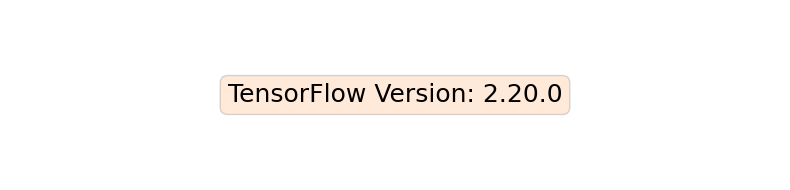

✅ tensorflow_version.png kaydedildi.


In [4]:
# Görev 1: TensorFlow versiyonunu hem print hem görsel olarak göster
version = tf.__version__
print(f"TensorFlow Version: {version}")

plt.figure(figsize=(8, 2))
plt.text(0.5, 0.5, f"TensorFlow Version: {version}",
         fontsize=18, ha='center', va='center',
         bbox=dict(boxstyle='round', facecolor='#ff6f00', alpha=0.15))
plt.axis('off')
plt.tight_layout()
plt.savefig("tensorflow_version.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ tensorflow_version.png kaydedildi.")

---
## 📦 2. Veri İndirme ve Hazırlama

**Veri Seti:** [Waste Classification Data (Kaggle)](https://www.kaggle.com/datasets/techsash/waste-classification-data)  
Bu notebook için IBM Cloud'dan indirilen küçültülmüş sürüm (1200 görüntü) kullanılır.

```
o-vs-r-split/
├── train/
│   ├── O/   ← Organik atık
│   └── R/   ← Geri dönüştürülebilir atık
└── test/
    ├── O/
    └── R/
```

In [5]:
import requests
import zipfile
from tqdm import tqdm

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/kd6057VPpABQ2FqCbgu9YQ/o-vs-r-split-reduced-1200.zip"
file_name = "o-vs-r-split-reduced-1200.zip"

# Daha önce indirilmişse tekrar indirme
if not os.path.exists("o-vs-r-split"):
    print("📥 Veri seti indiriliyor...")
    with requests.get(url, stream=True) as response:
        response.raise_for_status()
        total = int(response.headers.get('content-length', 0))
        with open(file_name, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc="İndiriliyor") as bar:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
                bar.update(len(chunk))

    print("📂 Çıkartılıyor...")
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        members = zip_ref.infolist()
        with tqdm(total=len(members), unit='file', desc="Çıkartılıyor") as bar:
            for member in members:
                zip_ref.extract(member)
                bar.update(1)
    os.remove(file_name)
    print("✅ Veri seti hazır.")
else:
    print("✅ Veri seti zaten mevcut, yeniden indirilmedi.")

📥 Veri seti indiriliyor...


İndiriliyor: 100%|██████████| 11.0M/11.0M [00:01<00:00, 5.68MB/s]


📂 Çıkartılıyor...


Çıkartılıyor: 100%|██████████| 1207/1207 [00:00<00:00, 2183.61file/s]

✅ Veri seti hazır.


In [6]:
# Veri setini keşfet
train_O = glob.glob('./o-vs-r-split/train/O/*')
train_R = glob.glob('./o-vs-r-split/train/R/*')
test_O  = glob.glob('./o-vs-r-split/test/O/*')
test_R  = glob.glob('./o-vs-r-split/test/R/*')

print("📊 Veri Seti İstatistikleri:")
print(f"  Train — Organik  (O): {len(train_O)} görüntü")
print(f"  Train — Recycle  (R): {len(train_R)} görüntü")
print(f"  Test  — Organik  (O): {len(test_O)} görüntü")
print(f"  Test  — Recycle  (R): {len(test_R)} görüntü")
print(f"  Toplam           : {len(train_O)+len(train_R)+len(test_O)+len(test_R)} görüntü")

📊 Veri Seti İstatistikleri:
  Train — Organik  (O): 500 görüntü
  Train — Recycle  (R): 500 görüntü
  Test  — Organik  (O): 100 görüntü
  Test  — Recycle  (R): 100 görüntü
  Toplam           : 1200 görüntü


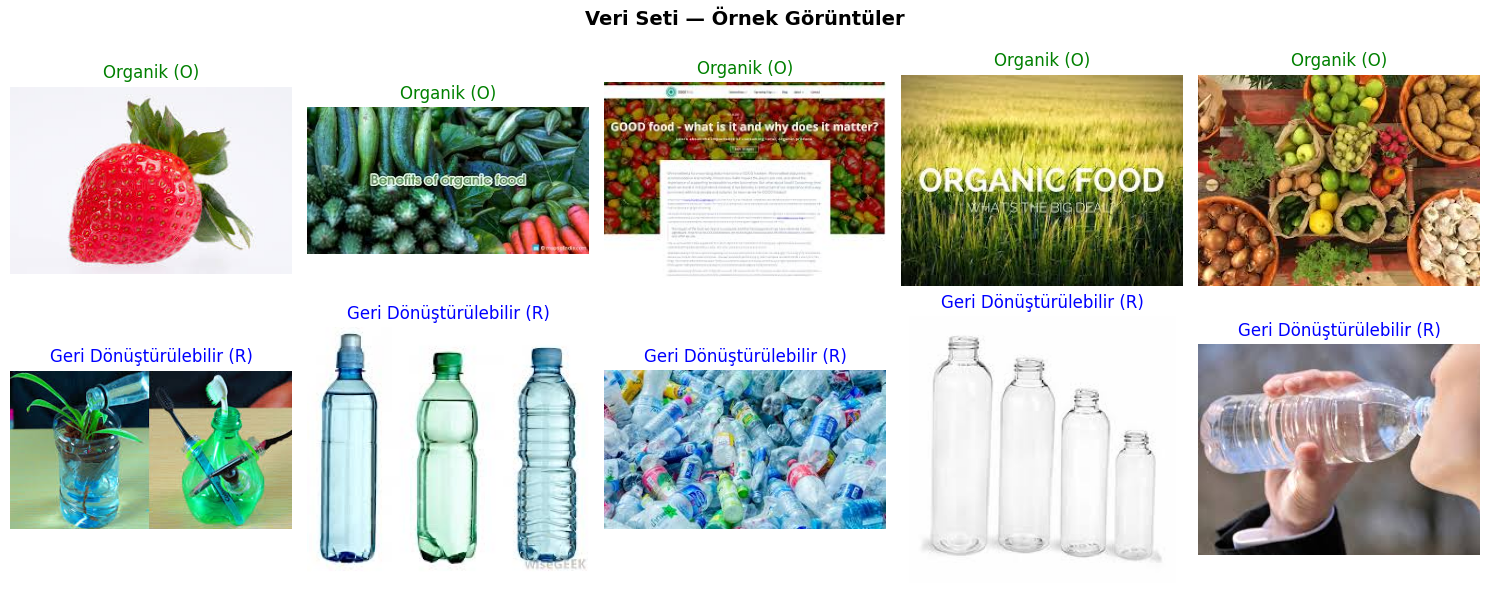

In [7]:
# Örnek görüntüleri görselleştir
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Veri Seti — Örnek Görüntüler", fontsize=14, fontweight='bold')

for i, fpath in enumerate(train_O[:5]):
    img = plt.imread(fpath)
    axes[0, i].imshow(img)
    axes[0, i].set_title("Organik (O)", color='green')
    axes[0, i].axis('off')

for i, fpath in enumerate(train_R[:5]):
    img = plt.imread(fpath)
    axes[1, i].imshow(img)
    axes[1, i].set_title("Geri Dönüştürülebilir (R)", color='blue')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ Model Konfigürasyonu

In [8]:
# ── Hiperparametreler ────────────────────────────────────────────────────────
img_rows, img_cols = 150, 150   # Görüntü boyutu
batch_size        = 32           # Her iterasyonda işlenen görüntü sayısı
n_epochs          = 10           # Maksimum epoch sayısı
n_classes         = 2            # Sınıf sayısı: O ve R
val_split         = 0.2          # Train verisinin %20'si validation için
verbosity         = 1
seed              = 42           # Tekrarlanabilirlik için sabit seed

path      = 'o-vs-r-split/train/'
path_test = 'o-vs-r-split/test/'
input_shape = (img_rows, img_cols, 3)
labels = ['O', 'R']

print("✅ Konfigürasyon:")
print(f"  Görüntü boyutu  : {img_rows}×{img_cols}")
print(f"  Batch size       : {batch_size}")
print(f"  Epoch sayısı     : {n_epochs}")
print(f"  Validation oranı : {int(val_split*100)}%")

✅ Konfigürasyon:
  Görüntü boyutu  : 150×150
  Batch size       : 32
  Epoch sayısı     : 10
  Validation oranı : 20%


---
## 🔄 3. ImageDataGenerators

**Data Augmentation** (Veri Artırma): Eğitim verisini çeşitlendirerek modelin genelleme yeteneğini artırır.  
Test/Validation verisine augmentation **uygulanmaz** — sadece normalize edilir.

In [9]:
# Eğitim: augmentation + normalize
train_datagen = ImageDataGenerator(
    validation_split=val_split,
    rescale=1.0/255.0,         # Piksel değerlerini [0,1] aralığına normalize eder
    width_shift_range=0.1,     # Yatay kaydırma (%10)
    height_shift_range=0.1,    # Dikey kaydırma (%10)
    horizontal_flip=True       # Yatay aynalama
)

# Validation: sadece normalize
val_datagen = ImageDataGenerator(
    validation_split=val_split,
    rescale=1.0/255.0
)

# Test: sadece normalize
test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)
print("✅ ImageDataGenerator nesneleri oluşturuldu.")

✅ ImageDataGenerator nesneleri oluşturuldu.


In [10]:
train_generator = train_datagen.flow_from_directory(
    directory=path,
    seed=seed,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True,
    target_size=(img_rows, img_cols),
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    directory=path,
    seed=seed,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True,
    target_size=(img_rows, img_cols),
    subset='validation'
)

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


### 🔖 Görev 2: `test_generator` Oluştur

In [11]:
# Görev 2: test_datagen kullanarak test_generator oluştur
test_generator = test_datagen.flow_from_directory(
    directory=path_test,
    class_mode='binary',
    seed=seed,
    batch_size=batch_size,
    shuffle=False,            # Test sırasında karıştırma yapma!
    target_size=(img_rows, img_cols)
)
print(f"✅ test_generator oluşturuldu — {test_generator.samples} test görüntüsü")
plt.savefig("test_generator.png", bbox_inches='tight')

Found 200 images belonging to 2 classes.
✅ test_generator oluşturuldu — 200 test görüntüsü


<Figure size 640x480 with 0 Axes>

### 🔖 Görev 3: `train_generator` Uzunluğunu Yazdır

In [12]:
# Görev 3: train_generator uzunluğunu yazdır
train_len = len(train_generator)
print(f"train_generator uzunluğu (batch sayısı): {train_len}")
print(f"Toplam eğitim görüntüsü                : {train_generator.samples}")
print(f"Batch size                              : {batch_size}")

train_generator uzunluğu (batch sayısı): 25
Toplam eğitim görüntüsü                : 800
Batch size                              : 32


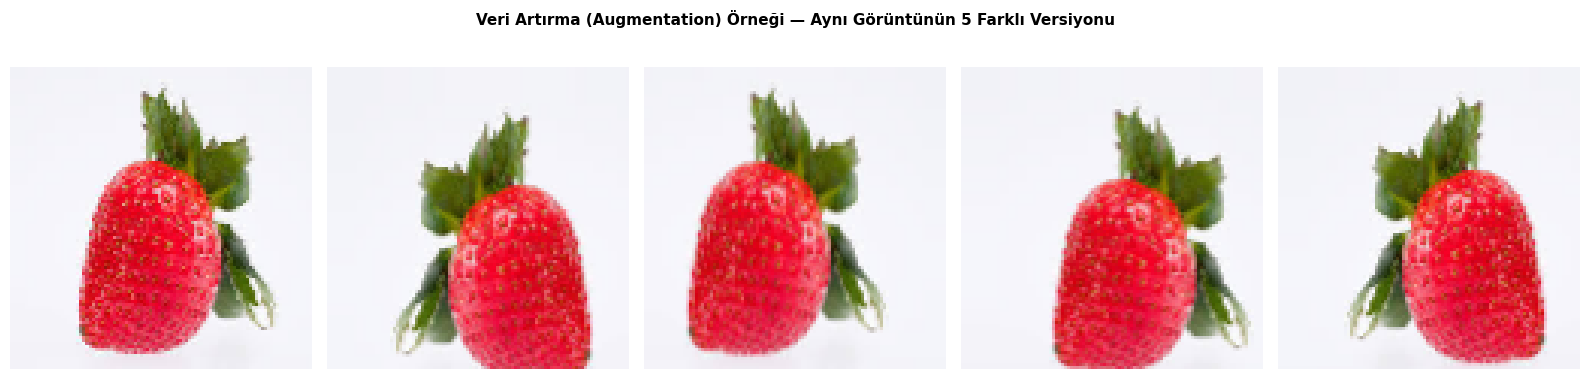

In [34]:
# Augment edilmiş örnek görüntüler — veri artırmanın etkisini göster
IMG_DIM = (100, 100)
train_files = glob.glob('./o-vs-r-split/train/O/*')[:20]
train_imgs  = [tf.keras.preprocessing.image.img_to_array(
                  tf.keras.preprocessing.image.load_img(f, target_size=IMG_DIM))
               for f in train_files]
train_imgs   = np.array(train_imgs)
train_labels = [Path(fn).parent.name for fn in train_files]

O_generator = train_datagen.flow(train_imgs[0:1], train_labels[0:1], batch_size=1)
O_aug = [next(O_generator) for _ in range(5)]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Veri Artırma (Augmentation) Örneği — Aynı Görüntünün 5 Farklı Versiyonu",
             fontsize=11, fontweight='bold')
for i in range(5):
    img = O_aug[i][0][0]
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].axis('off')
plt.tight_layout()
plt.savefig("augmentation_examples.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 🧠 4. VGG16 Modeli — Feature Extraction

### Transfer Learning Nedir?
VGG16, ImageNet üzerinde 1000 sınıf tanımak için eğitilmiştir.  
Alt katmanlar genel özellikler öğrenir (kenarlar, dokular, şekiller) → bunları **donduruyoruz**.  
Üst katmanlara kendi veri setimize özel yeni katmanlar ekliyoruz.

```
VGG16 (frozen — ImageNet ağırlıkları)
     ↓
Flatten
     ↓
Dense(512, relu) → Dropout(0.3)
     ↓
Dense(512, relu) → Dropout(0.3)
     ↓
Dense(1, sigmoid)  ← Binary output: O veya R
```

In [14]:
from tensorflow.keras.applications import vgg16

input_shape = (150, 150, 3)

# VGG16'yı ImageNet ağırlıklarıyla yükle, üst (classification) katmanlar hariç
vgg = vgg16.VGG16(include_top=False,
                  weights='imagenet',
                  input_shape=input_shape)

# Son conv katmanının çıktısını düzleştir
output    = vgg.layers[-1].output
output    = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

# Tüm VGG katmanlarını dondur (eğitim sırasında güncellenmeyecek)
for layer in basemodel.layers:
    layer.trainable = False

print(f"✅ VGG16 yüklendi — {len(basemodel.layers)} katman, hepsi donduruldu")

✅ VGG16 yüklendi — 20 katman, hepsi donduruldu


In [15]:
# Üstüne yeni sınıflandırma katmanları ekle
model = Sequential([
    basemodel,
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # Binary: 0=Organik, 1=Geri Dönüştürülebilir
])

### 🔖 Görev 4: Model Özetini Yazdır

In [16]:
# Görev 4: Model özetini yazdır
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 8192)           │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,172,673 (73.14 MB)

 Trainable params: 4,457,985 (17.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 🔖 Görev 5: Modeli Derle (Compile)

In [17]:
# Görev 5: Modeli compile et
for layer in basemodel.layers:
    layer.trainable = False

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=['accuracy']
)
print("✅ Model derlendi.")
print(f"   Optimizer   : Adam  (lr=1e-5)")
print(f"   Loss        : binary_crossentropy")
print(f"   Metrics     : accuracy")

✅ Model derlendi.
   Optimizer   : Adam  (lr=1e-5)
   Loss        : binary_crossentropy
   Metrics     : accuracy


---
## 🏋️ 5. Modeli Eğit — Feature Extraction

**Callbacks:**
- **EarlyStopping**: val_loss 4 epoch iyileşmezse eğitimi durdur
- **ModelCheckpoint**: en iyi modeli kaydet
- **LearningRateScheduler**: epoch ilerledikçe learning rate'i üstel olarak düşür

In [18]:
checkpoint_path = 'O_R_tlearn_vgg16.keras'

class LossHistory_(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.lr     = []
    def on_epoch_end(self, epoch, logs={}):
        self.losses.append(logs.get('loss'))
        self.lr.append(exp_decay(epoch))

def exp_decay(epoch):
    initial_lrate = 1e-4
    k = 0.1
    return initial_lrate * np.exp(-k * epoch)

loss_history_ = LossHistory_()
lrate_        = LearningRateScheduler(exp_decay)

keras_callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, mode='min', min_delta=0.01),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min')
]

callbacks_list_ = [loss_history_, lrate_] + keras_callbacks
print("✅ Callback'ler ayarlandı.")

✅ Callback'ler ayarlandı.


In [19]:
print("🚀 Feature Extraction modeli eğitiliyor...")
extract_feat_model = model.fit(
    train_generator,
    steps_per_epoch=5,
    epochs=n_epochs,
    callbacks=callbacks_list_,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    verbose=1
)
print("✅ Eğitim tamamlandı.")

🚀 Feature Extraction modeli eğitiliyor...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5688 - loss: 0.6552 - val_accuracy: 0.7760 - val_loss: 0.5610 - learning_rate: 1.0000e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7063 - loss: 0.5865 - val_accuracy: 0.6875 - val_loss: 0.5544 - learning_rate: 9.0484e-05
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7250 - loss: 0.5467 - val_accuracy: 0.8177 - val_loss: 0.4462 - learning_rate: 8.1873e-05
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7437 - loss: 0.4980 - val_accuracy: 0.8177 - val_loss: 0.4216 - learning_rate: 7.4082e-05
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7875 - loss: 0.4734 - val_accuracy: 0.8281 - val_loss: 0.4150 - learning_rate: 6.7032e-05
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7500 - loss: 0.5215 - val_accuracy: 0.8177 - val_loss: 0.4073 - learning_rate: 6.0653e-05
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - ac

### 📈 Feature Extraction — Kayıp (Loss) Eğrileri

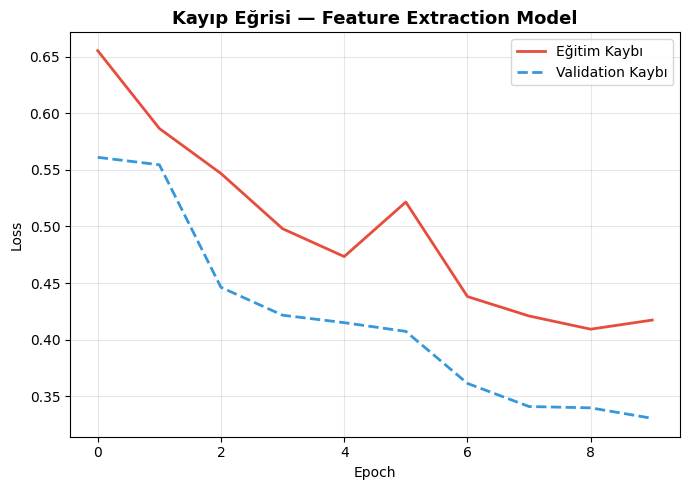

In [20]:
history = extract_feat_model

plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'],     label='Eğitim Kaybı',    color='#e74c3c', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Kaybı', color='#3498db', linewidth=2, linestyle='--')
plt.title('Kayıp Eğrisi — Feature Extraction Model', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve_extract.png", dpi=150, bbox_inches='tight')
plt.show()

### 🔖 Görev 6: Feature Extraction — Doğruluk (Accuracy) Eğrileri

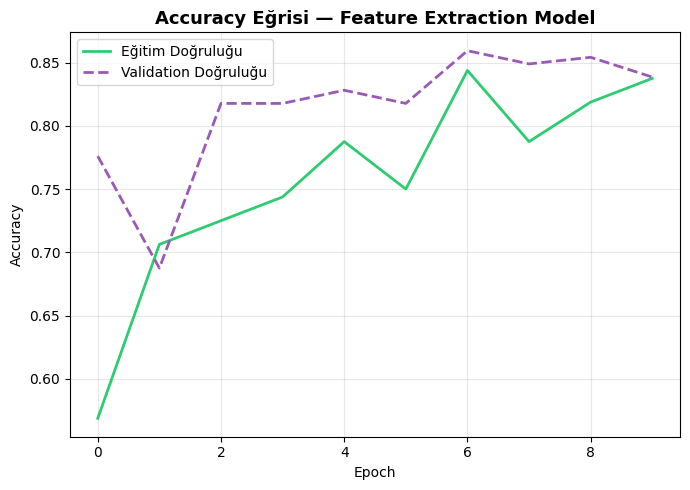

In [21]:
# Görev 6: Accuracy eğrilerini çiz (Feature Extraction Model)
history = extract_feat_model

plt.figure(figsize=(7, 5))
plt.plot(history.history['accuracy'],     label='Eğitim Doğruluğu',    color='#2ecc71', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Doğruluğu', color='#9b59b6', linewidth=2, linestyle='--')
plt.title('Accuracy Eğrisi — Feature Extraction Model', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot_accuracy_curve.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 🔧 6. Fine-Tuning

Feature Extraction'dan sonra VGG16'nın son konvolüsyon bloğunu (`block5_conv3`) **çözüyoruz** ve modeli yeniden eğitiyoruz.  
Bu sayede model, kendi veri setimize daha iyi adapte olur.

> ⚠️ Fine-tuning için **daha küçük bir learning rate** kullanıyoruz (önceden öğrenilen ağırlıkları çok fazla değiştirmemek için).

In [22]:
from tensorflow.keras.applications import vgg16

# VGG16'yı yeniden yükle
vgg = vgg16.VGG16(include_top=False, weights='imagenet', input_shape=(150, 150, 3))
output    = vgg.layers[-1].output
output    = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

# Tüm katmanları önce dondur
for layer in basemodel.layers:
    layer.trainable = False

# Hangi katmanlar mevcut?
print("VGG16 Katmanları:")
for layer in basemodel.layers:
    print(f"  {layer.name:25s} trainable={layer.trainable}")

VGG16 Katmanları:
  input_layer_2             trainable=False
  block1_conv1              trainable=False
  block1_conv2              trainable=False
  block1_pool               trainable=False
  block2_conv1              trainable=False
  block2_conv2              trainable=False
  block2_pool               trainable=False
  block3_conv1              trainable=False
  block3_conv2              trainable=False
  block3_conv3              trainable=False
  block3_pool               trainable=False
  block4_conv1              trainable=False
  block4_conv2              trainable=False
  block4_conv3              trainable=False
  block4_pool               trainable=False
  block5_conv1              trainable=False
  block5_conv2              trainable=False
  block5_conv3              trainable=False
  block5_pool               trainable=False
  flatten_1                 trainable=False


In [23]:
# Sadece block5_conv3 ve sonrasını çöz (unfreeze)
set_trainable = False
for layer in basemodel.layers:
    if layer.name == 'block5_conv3':
        set_trainable = True
    if set_trainable:
        layer.trainable = True

print("\n✅ Fine-tuning için güncellenen katmanlar:")
for layer in basemodel.layers:
    if layer.trainable:
        print(f"  🔓 {layer.name} — EĞİTİLEBİLİR")


✅ Fine-tuning için güncellenen katmanlar:
  🔓 block5_conv3 — EĞİTİLEBİLİR
  🔓 block5_pool — EĞİTİLEBİLİR
  🔓 flatten_1 — EĞİTİLEBİLİR


In [24]:
# Fine-tune modeli oluştur
model = Sequential([
    basemodel,
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

checkpoint_path_ft = 'O_R_tlearn_fine_tune_vgg16.keras'

loss_history_ = LossHistory_()
lrate_        = LearningRateScheduler(exp_decay)

keras_callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, mode='min', min_delta=0.01),
    ModelCheckpoint(checkpoint_path_ft, monitor='val_loss', save_best_only=True, mode='min')
]
callbacks_list_ = [loss_history_, lrate_] + keras_callbacks

# Fine-tuning için RMSprop ve daha küçük lr
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

print("🚀 Fine-Tuning eğitimi başlıyor...")
fine_tune_model = model.fit(
    train_generator,
    steps_per_epoch=5,
    epochs=n_epochs,
    callbacks=callbacks_list_,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    verbose=1
)
print("✅ Fine-Tuning tamamlandı.")

🚀 Fine-Tuning eğitimi başlıyor...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5625 - loss: 0.7185 - val_accuracy: 0.7708 - val_loss: 0.5469 - learning_rate: 1.0000e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6812 - loss: 0.5977 - val_accuracy: 0.7344 - val_loss: 0.5040 - learning_rate: 9.0484e-05
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7500 - loss: 0.5314 - val_accuracy: 0.8229 - val_loss: 0.4082 - learning_rate: 8.1873e-05
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7625 - loss: 0.4831 - val_accuracy: 0.8229 - val_loss: 0.3824 - learning_rate: 7.4082e-05
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7875 - loss: 0.4035 - val_accuracy: 0.8229 - val_loss: 0.3527 - learning_rate: 6.7032e-05
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8375 - loss: 0.4005 - val_accuracy: 0.8438 - val_loss: 0.3303 - learning_rate: 6.0653e-05
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy:

### 🔖 Görev 7: Fine-Tune Model — Kayıp (Loss) Eğrileri

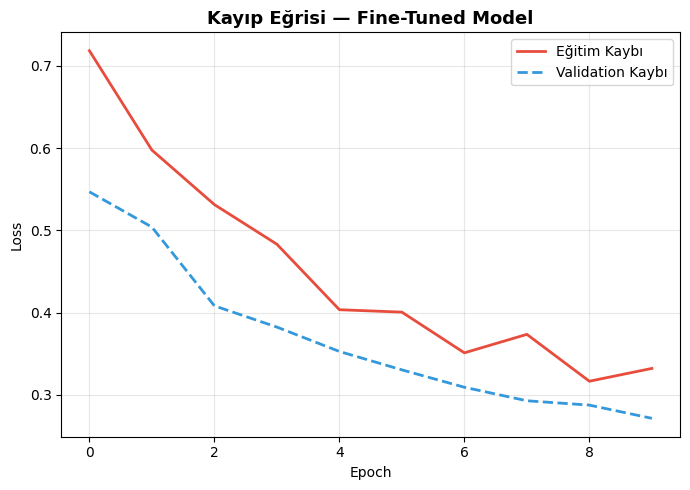

In [25]:
# Görev 7: Fine-tune model için loss eğrilerini çiz
history = fine_tune_model

plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'],     label='Eğitim Kaybı',    color='#e74c3c', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Kaybı', color='#3498db', linewidth=2, linestyle='--')
plt.title('Kayıp Eğrisi — Fine-Tuned Model', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot_loss_curve.png", dpi=150, bbox_inches='tight')
plt.show()

### 🔖 Görev 8: Fine-Tune Model — Doğruluk (Accuracy) Eğrileri

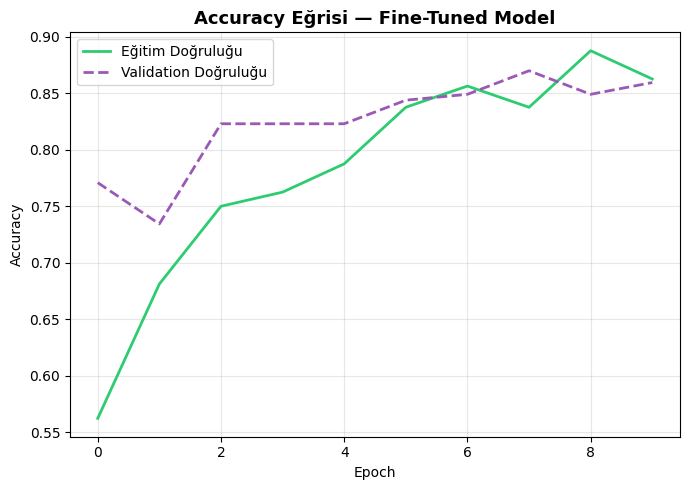

In [26]:
# Görev 8: Fine-tune model için accuracy eğrilerini çiz
history = fine_tune_model

plt.figure(figsize=(7, 5))
plt.plot(history.history['accuracy'],     label='Eğitim Doğruluğu',    color='#2ecc71', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Doğruluğu', color='#9b59b6', linewidth=2, linestyle='--')
plt.title('Accuracy Eğrisi — Fine-Tuned Model', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot_finetune_model.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 🧪 7. Test ve Değerlendirme

Her iki modeli kayıtlı `.keras` dosyalarından yükleyip test setinde değerlendiriyoruz.

In [27]:
# Kaydedilen modelleri yükle
extract_feat_model_loaded = tf.keras.models.load_model('O_R_tlearn_vgg16.keras')
fine_tune_model_loaded    = tf.keras.models.load_model('O_R_tlearn_fine_tune_vgg16.keras')

IMG_DIM = (150, 150)

# Test görüntülerini yükle
test_files_O = glob.glob('./o-vs-r-split/test/O/*')
test_files_R = glob.glob('./o-vs-r-split/test/R/*')
test_files   = test_files_O[:50] + test_files_R[:50]

test_imgs = np.array([
    tf.keras.preprocessing.image.img_to_array(
        tf.keras.preprocessing.image.load_img(f, target_size=IMG_DIM))
    for f in test_files
])
test_labels = [Path(fn).parent.name for fn in test_files]

# Normalize
test_imgs_scaled = test_imgs.astype('float32') / 255.0

class2num_lt = lambda l: [0 if x == 'O' else 1 for x in l]
num2class_lt = lambda l: ['O' if x < 0.5 else 'R' for x in l]
test_labels_enc = class2num_lt(test_labels)

# Tahminler
predictions_extract = num2class_lt(extract_feat_model_loaded.predict(test_imgs_scaled, verbose=0))
predictions_fine    = num2class_lt(fine_tune_model_loaded.predict(test_imgs_scaled, verbose=0))

# Sonuçlar
print("=" * 55)
print("📊 Feature Extraction Model — Classification Report")
print("=" * 55)
print(metrics.classification_report(test_labels, predictions_extract, target_names=['Organik(O)', 'Recycle(R)']))

print("=" * 55)
print("📊 Fine-Tuned Model — Classification Report")
print("=" * 55)
print(metrics.classification_report(test_labels, predictions_fine, target_names=['Organik(O)', 'Recycle(R)']))

📊 Feature Extraction Model — Classification Report
              precision    recall  f1-score   support

  Organik(O)       0.74      0.78      0.76        50
  Recycle(R)       0.77      0.72      0.74        50

    accuracy                           0.75       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.75      0.75      0.75       100

📊 Fine-Tuned Model — Classification Report
              precision    recall  f1-score   support

  Organik(O)       0.81      0.88      0.85        50
  Recycle(R)       0.87      0.80      0.83        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



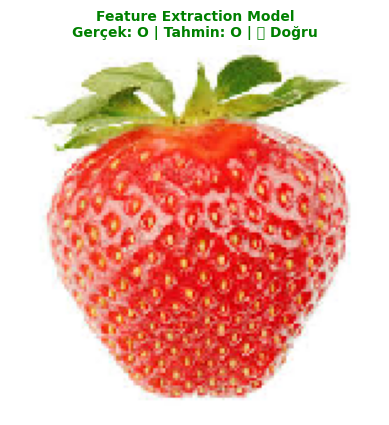

In [28]:
# Yardımcı fonksiyon: görüntüyü tahminle birlikte göster
def plot_image_with_title(image, model_name, actual_label, predicted_label):
    color = 'green' if actual_label == predicted_label else 'red'
    status = '✅ Doğru' if actual_label == predicted_label else '❌ Yanlış'
    plt.imshow(image)
    plt.title(f"{model_name}\nGerçek: {actual_label} | Tahmin: {predicted_label} | {status}",
              color=color, fontsize=10, fontweight='bold')
    plt.axis('off')
    plt.show()

# index=0 örneği (mevcut)
index_to_plot = 0
plot_image_with_title(
    image=test_imgs[index_to_plot].astype('uint8'),
    model_name='Feature Extraction Model',
    actual_label=test_labels[index_to_plot],
    predicted_label=predictions_extract[index_to_plot]
)

### 🔖 Görev 9: Extract Features Model ile Test Görüntüsü (index=1)

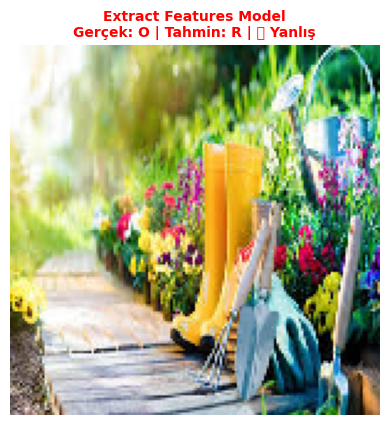

<Figure size 640x480 with 0 Axes>

In [29]:
# Görev 9: index_to_plot = 1 ile Extract Features Model tahmini
index_to_plot = 1
plot_image_with_title(
    image=test_imgs[index_to_plot].astype('uint8'),
    model_name='Extract Features Model',
    actual_label=test_labels[index_to_plot],
    predicted_label=predictions_extract[index_to_plot]
)
plt.savefig("extract_features_model.png", dpi=150, bbox_inches='tight')

### 🔖 Görev 10: Fine-Tuned Model ile Test Görüntüsü (index=1)

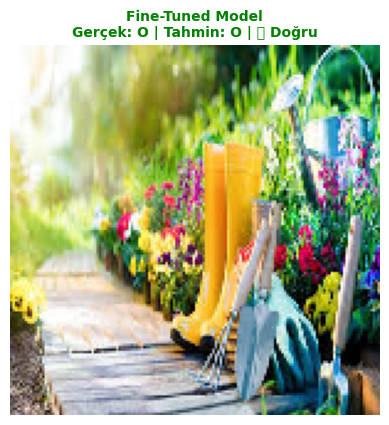

<Figure size 640x480 with 0 Axes>

In [30]:
# Görev 10: index_to_plot = 1 ile Fine-Tuned Model tahmini
index_to_plot = 1
plot_image_with_title(
    image=test_imgs[index_to_plot].astype('uint8'),
    model_name='Fine-Tuned Model',
    actual_label=test_labels[index_to_plot],
    predicted_label=predictions_fine[index_to_plot]
)
plt.savefig("finetuned_model.png", dpi=150, bbox_inches='tight')

---
## 📝 Sonuç ve Özet

Bu projede:

1. **Transfer Learning** ile VGG16 modelini kullandık — ImageNet'ten öğrenilen ağırlıkları küçük bir atık veri setine uyguladık
2. **Feature Extraction** aşamasında tüm VGG16 katmanlarını dondurarak sadece üst katmanları eğittik
3. **Fine-Tuning** aşamasında `block5_conv3` ve sonraki katmanları açarak modeli daha da iyileştirdik
4. İki modeli test seti üzerinde karşılaştırdık

### Transfer Learning'in Avantajları
- Az veri ile yüksek doğruluk
- Sıfırdan eğitime kıyasla çok daha hızlı
- Genel görsel özellikler (kenar, doku, şekil) zaten öğrenilmiş

### Gerçek Dünya Uygulaması
Bu model; belediye atık tesisleri, akıllı çöp kutuları veya endüstriyel geri dönüşüm hatlarında kullanılabilecek bir sistemin temelini oluşturur.

